In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif

In [5]:
# Veriyi yükle
data = pd.read_csv("data/heart_statlog_cleveland_hungary_final.csv")



# Tekrar eden verilerin kontrolü
print("Veri Seti Boyutu:", data.shape)
duplicates = data.duplicated()
print("Tekrar Eden Veri Sayısı:", duplicates.sum())

# Tekrar eden verileri silme
data.drop_duplicates(inplace=True)

# Sonuç kontrolü
print("Tekrar Eden Veri Silindikten Sonra Veri Seti Boyutu:", data.shape)






# Hedef değişken (target) ve özellikleri ayır
X = data.drop(columns=["target"])
y = data["target"]

# Eğitim ve test setlerini böl
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Özellikleri ölçeklendir
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Veri Seti Boyutu: (1190, 12)
Tekrar Eden Veri Sayısı: 272
Tekrar Eden Veri Silindikten Sonra Veri Seti Boyutu: (918, 12)


In [6]:
# ANOVA F-test kullanarak en iyi 5 özelliği seç
selector = SelectKBest(score_func=f_classif, k=6)
X_train_selected = selector.fit_transform(X_train_scaled, y_train)
X_test_selected = selector.transform(X_test_scaled)

# Seçilen özelliklerin indekslerini al
selected_features = selector.get_support(indices=True)
selected_feature_names = X.columns[selected_features]

print("Seçilen Özellikler:", selected_feature_names)

Seçilen Özellikler: Index(['sex', 'chest pain type', 'max heart rate', 'exercise angina',
       'oldpeak', 'ST slope'],
      dtype='object')


In [7]:
# Karar ağacı modelini oluştur
tree_model = DecisionTreeClassifier(random_state=42, max_depth=5)
tree_model.fit(X_train_selected, y_train)

# Test seti üzerinde tahmin yap
y_pred = tree_model.predict(X_test_selected)

# Performans metriklerini hesapla
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

print("Doğruluk:", accuracy)
print("Karışıklık Matrisi:\n", conf_matrix)
print("Sınıflandırma Raporu:\n", class_report)

Doğruluk: 0.8260869565217391
Karışıklık Matrisi:
 [[69  8]
 [24 83]]
Sınıflandırma Raporu:
               precision    recall  f1-score   support

           0       0.74      0.90      0.81        77
           1       0.91      0.78      0.84       107

    accuracy                           0.83       184
   macro avg       0.83      0.84      0.83       184
weighted avg       0.84      0.83      0.83       184



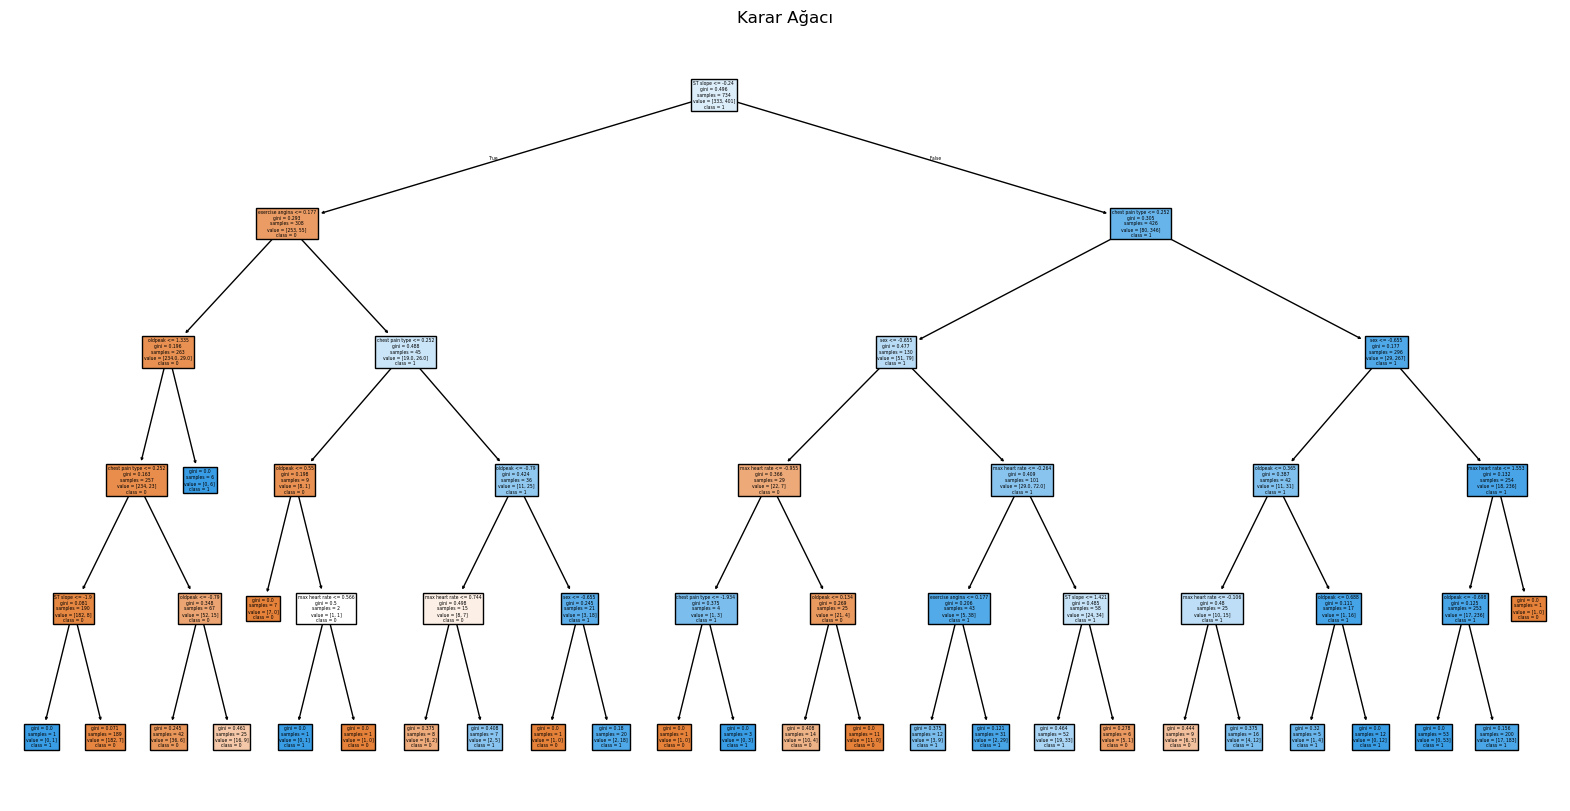

Karar Kuralları:
 |--- ST slope <= -0.24
|   |--- exercise angina <= 0.18
|   |   |--- oldpeak <= 1.34
|   |   |   |--- chest pain type <= 0.25
|   |   |   |   |--- ST slope <= -1.90
|   |   |   |   |   |--- class: 1
|   |   |   |   |--- ST slope >  -1.90
|   |   |   |   |   |--- class: 0
|   |   |   |--- chest pain type >  0.25
|   |   |   |   |--- oldpeak <= -0.79
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- oldpeak >  -0.79
|   |   |   |   |   |--- class: 0
|   |   |--- oldpeak >  1.34
|   |   |   |--- class: 1
|   |--- exercise angina >  0.18
|   |   |--- chest pain type <= 0.25
|   |   |   |--- oldpeak <= 0.55
|   |   |   |   |--- class: 0
|   |   |   |--- oldpeak >  0.55
|   |   |   |   |--- max heart rate <= 0.57
|   |   |   |   |   |--- class: 1
|   |   |   |   |--- max heart rate >  0.57
|   |   |   |   |   |--- class: 0
|   |   |--- chest pain type >  0.25
|   |   |   |--- oldpeak <= -0.79
|   |   |   |   |--- max heart rate <= 0.74
|   |   |   |   |   |--- class: 0

In [8]:
# Karar ağacını görselleştir
plt.figure(figsize=(20, 10))
plot_tree(tree_model, feature_names=selected_feature_names, class_names=["0", "1"], filled=True)
plt.title("Karar Ağacı")
plt.show()

# Karar kurallarını metin olarak yazdır
tree_rules = export_text(tree_model, feature_names=selected_feature_names.tolist())
print("Karar Kuralları:\n", tree_rules)

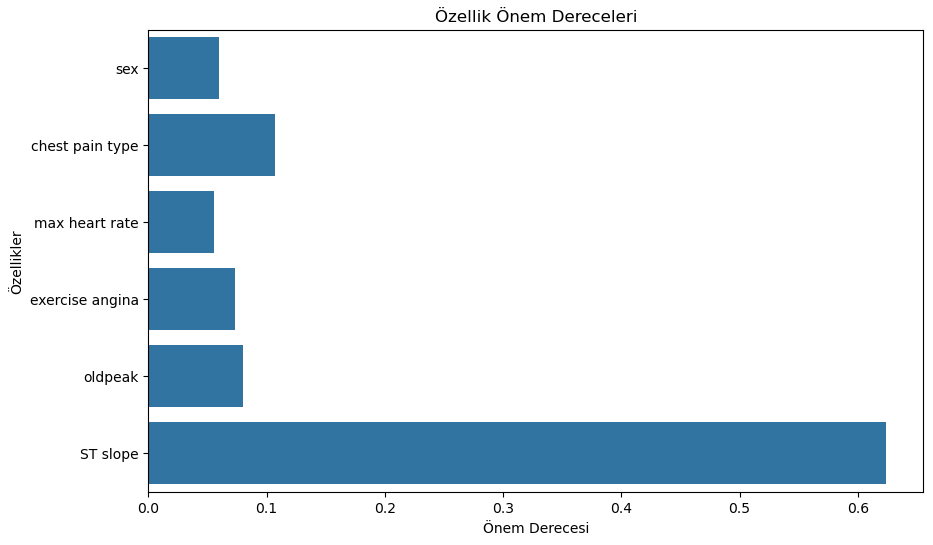

In [9]:
# Özellik önem derecelerini al
feature_importances = tree_model.feature_importances_

# Önem derecelerini görselleştir
plt.figure(figsize=(10, 6))
sns.barplot(x=feature_importances, y=selected_feature_names)
plt.title("Özellik Önem Dereceleri")
plt.xlabel("Önem Derecesi")
plt.ylabel("Özellikler")
plt.show()

Doğruluk: 0.8487394957983193
Karışıklık Matrisi:
 [[ 80  27]
 [  9 122]]
Sınıflandırma Raporu:
               precision    recall  f1-score   support

           0       0.90      0.75      0.82       107
           1       0.82      0.93      0.87       131

    accuracy                           0.85       238
   macro avg       0.86      0.84      0.84       238
weighted avg       0.85      0.85      0.85       238
